# W11

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import random
import scipy.stats as stats

In [2]:
data = np.load('/Users/lorenzaimpicicche/Desktop/astrostatistics_bicocca_2025/solutions/transient.npy')

Text(0, 0.5, 'Flusso')

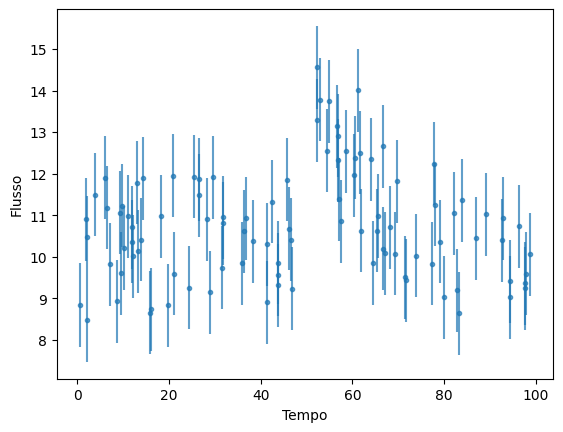

In [3]:
t, flux, err = data[:, 0], data[:, 1], data[:, 2]
plt.errorbar(t, flux, yerr=err, fmt='.', label='Osservazioni', alpha=0.7)
plt.xlabel("Tempo")
plt.ylabel("Flusso")

In [4]:
def burst_model(t, b, A, t0, alpha):
    y = np.ones_like(t) * b
    after_t0 = t >= t0
    y[after_t0] += A * np.exp(-alpha * (t[after_t0] - t0))
    return y

def log_likelihood(theta, t, y, yerr):
    b, A, t0, ln_alpha = theta
    alpha = np.exp(ln_alpha)
    model = burst_model(t, b, A, t0, alpha)
    return -0.5 * np.sum(((y - model) / yerr) ** 2 + np.log(2 * np.pi * yerr ** 2))


In [6]:
# Prior uniformi
def log_prior(theta):
    b, A, t0, ln_alpha = theta
    if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < ln_alpha < 5:
        return 0.0
    return -np.inf

# Posterior
def log_posterior(theta, t, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, yerr)

# Inizializzazione MCMC
ndim = 4
nwalkers = 50
nsteps = 5000

# Avvio iniziale casuale per ogni walker
p0 = np.array([[np.random.uniform(10, 30),  # b
                np.random.uniform(10, 30),  # A
                np.random.uniform(40, 60),  # t0
                np.random.uniform(-2, 2)]   # ln_alpha
               for _ in range(nwalkers)])

# Sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t, flux, err))
sampler.run_mcmc(p0, nsteps, progress=True)

100%|█████████████████████████████████████| 5000/5000 [00:03<00:00, 1250.72it/s]


State([[10.41624879  7.71757739 46.94256867 -2.02113549]
 [10.45845607  8.88308462 48.62695743 -1.64421272]
 [10.28313484  3.96285933 51.15643461 -2.20265854]
 [10.30981454  4.15639121 51.81751944 -1.83403352]
 [10.45864163  7.01654153 47.92431507 -1.89575786]
 [10.28436998  4.03248467 50.30028381 -2.28455634]
 [10.3078413   4.11122213 51.68600881 -1.94032413]
 [10.41344519  4.61732073 50.60861468 -2.02143266]
 [10.44792992  5.56010897 47.69654382 -2.06001781]
 [10.29456569  5.68100685 49.82447899 -2.1190335 ]
 [10.37398361  3.19752489 51.79934795 -2.32296495]
 [10.48402584  4.50349686 52.11659036 -1.72095789]
 [10.30671072  7.76862218 47.76962896 -1.89919205]
 [10.31108141  7.27403554 46.96795277 -1.91056452]
 [10.03908539  5.47388326 50.43322532 -2.33390137]
 [10.19215197  4.30863857 50.63424164 -2.21275247]
 [10.1652509   6.93655168 48.69040431 -1.94845728]
 [10.45078708  7.8452044  47.848478   -1.79736017]
 [10.45075284  9.30995342 46.89684315 -1.9355978 ]
 [10.54382332  3.6330591 

In [9]:
# Rimuovi burn-in
burnin = 1000
samples = sampler.get_chain(discard=burnin, flat=False)

# Calcolo autocorrelazione
tau = sampler.get_autocorr_time(tol=0)
thin = int(np.mean(tau))  # Converti direttamente a intero senza .astype(int)

# Chain finale
flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
print(f"N. campioni dopo thinning: {len(flat_samples)}")

N. campioni dopo thinning: 2500


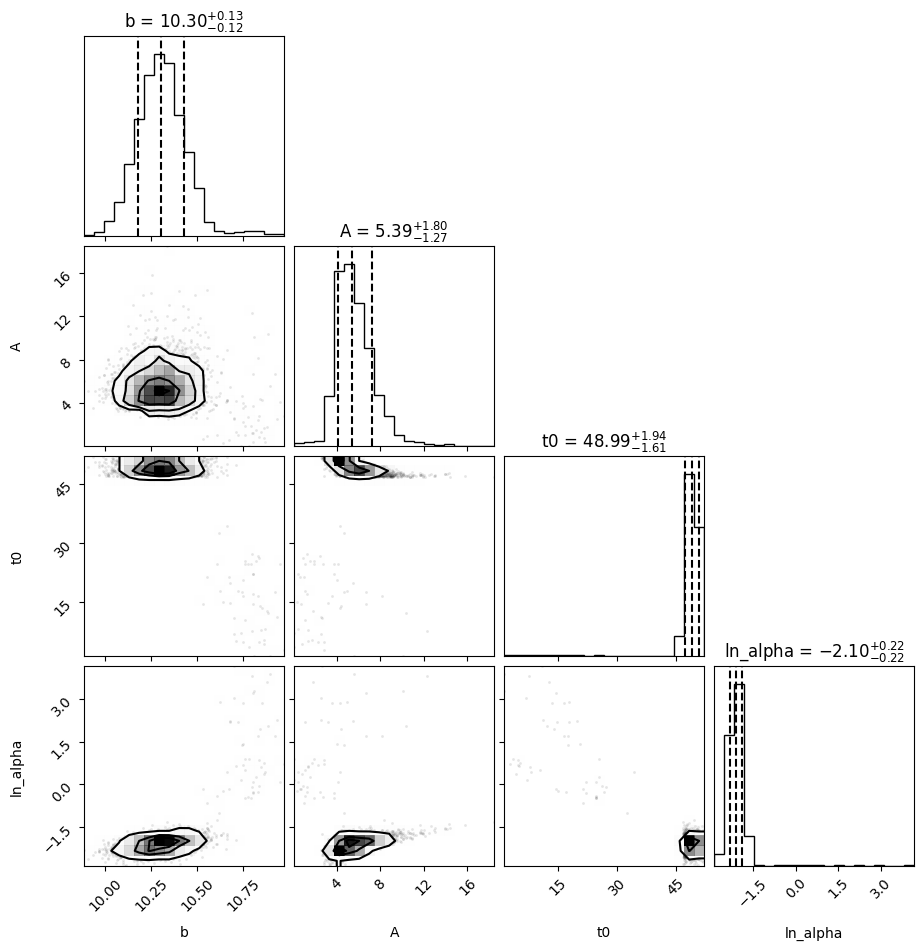

In [11]:
labels = ["b", "A", "t0", "ln_alpha"]
fig = corner.corner(flat_samples, labels=labels, 
                    quantiles=[0.16, 0.5, 0.84], 
                    show_titles=True, title_fmt=".2f", 
                    title_kwargs={"fontsize": 12})

Text(0.5, 1.0, 'Posterior predictive burst models')

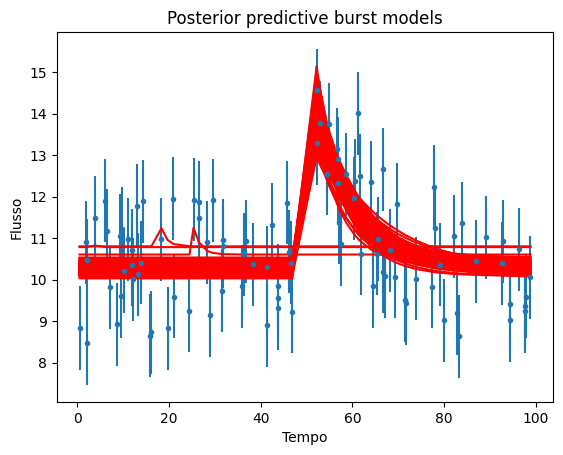

In [16]:
plt.errorbar(t, flux, yerr=err, fmt='.', label='Dati')

# Scegli 100 campioni
subset = flat_samples[np.random.choice(flat_samples.shape[0], 100, replace=False)]

# Disegna le curve
for s in subset:
    b, A, t0, ln_alpha = s
    alpha = np.exp(ln_alpha)
    model_flux = burst_model(t, b, A, t0, alpha)
    plt.plot(t, model_flux, color="red")

plt.xlabel("Tempo")
plt.ylabel("Flusso")
plt.title("Posterior predictive burst models")

In [13]:
for i, label in enumerate(labels):
    mcmc = np.percentile(flat_samples[:, i], [5, 50, 95])
    median = mcmc[1]
    lower = median - mcmc[0]
    upper = mcmc[2] - median
    print(f"{label} = {median:.2f}_{{-{lower:.2f}}}^{{+{upper:.2f}}}")


b = 10.30_{-0.20}^{+0.22}
A = 5.39_{-1.92}^{+3.41}
t0 = 48.99_{-2.00}^{+2.81}
ln_alpha = -2.10_{-0.37}^{+0.41}
